# Finding Duplicates in Survey Data

This is my own practice notebook based on what I learned in the IBM Data Analyst Capstone Project on Coursera.

## What this notebook is doing

I am checking whether the dataset contains duplicate rows, looking at repeated patterns in a few selected columns, and then verifying duplicate removal with pandas.

## 1) Import the libraries

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

### Why this step exists

- `pandas` lets me work with the dataset as a table.
- `matplotlib` lets me make simple charts if I want to inspect patterns visually.

## 2) Load the dataset

In [3]:
file_path = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/VYPrOu0Vs3I0hKLLjiPGrA/survey-data-with-duplicate.csv"
df = pd.read_csv(file_path)
print("Shape:", df.shape)
df.head()

Shape: (65457, 114)


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Why this step exists

This loads the CSV file into a pandas DataFrame called `df`. A DataFrame is just a table in Python.

## 3) Count exact duplicate rows

In [4]:
exact_duplicate_count = df.duplicated().sum()
print("Exact duplicate rows:", exact_duplicate_count)

Exact duplicate rows: 20


### What this means

`df.duplicated()` checks each full row and asks: have I seen this exact same row before?

`sum()` counts how many times the answer is `True`.

## 4) Show the duplicate rows

In [5]:
exact_duplicates = df[df.duplicated()]
exact_duplicates.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
65437,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
65438,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
65439,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
65440,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
65441,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Why this matters

Counting duplicates is not enough. I also want to inspect the repeated rows directly so I can see what is being duplicated.

## 5) Check repeated patterns in selected columns

In [6]:
subset_duplicates = df[df.duplicated(subset=['MainBranch', 'Employment', 'RemoteWork'], keep=False)]
subset_duplicates[['MainBranch', 'Employment', 'RemoteWork']].head()

,MainBranch,Employment,RemoteWork
0,I am a developer by profession,"Employed, full-time",Remote
1,I am a developer by profession,"Employed, full-time",Remote
2,I am a developer by profession,"Employed, full-time",Remote
3,I am learning to code,"Student, full-time",NaN
4,I am a developer by profession,"Student, full-time",NaN


### Important caution

This does **not** automatically mean these rows are true duplicate people or true duplicate records.

It only means the values in those selected columns repeat. Different respondents can share the same answers in those columns.

## 6) Quick look at repeated patterns

In [7]:
subset_duplicates[['Country', 'Employment']].head()

,Country,Employment
0,United States of America,"Employed, full-time"
1,United Kingdom of Great Britain and Northern I...,"Employed, full-time"
2,United Kingdom of Great Britain and Northern I...,"Employed, full-time"
3,Canada,"Student, full-time"
4,Norway,"Student, full-time"


## 7) Simple visual check

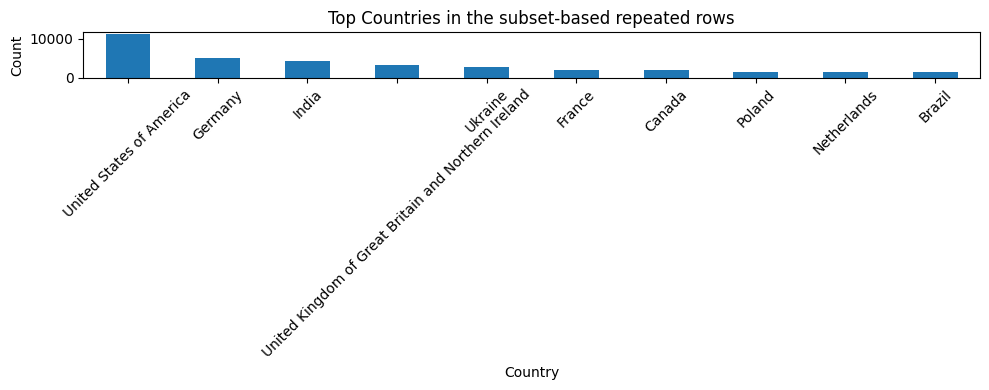

In [8]:
country_counts = subset_duplicates['Country'].value_counts().head(10)

country_counts.plot(kind='bar', figsize=(10, 4), title='Top Countries in the subset-based repeated rows')
plt.xlabel('Country')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Why I used a chart

The chart helps me see where repeated patterns appear most often in this subset. It is just a quick inspection step.

## 8) Remove duplicates with a chosen rule

In [9]:
df_cleaned = df.drop_duplicates(
    subset=['ResponseId', 'MainBranch', 'Employment', 'RemoteWork'],
    keep='first'
)

print("Rows before cleaning:", len(df))
print("Rows after cleaning:", len(df_cleaned))

Rows before cleaning: 65457
Rows after cleaning: 65437


### Why this step exists

I need a rule for what counts as the same record. Here I am using selected columns and keeping the first occurrence.

## 9) Verify that the chosen duplicate rule is cleared

In [10]:
remaining_duplicates = df_cleaned.duplicated(
    subset=['ResponseId', 'MainBranch', 'Employment', 'RemoteWork']
).sum()

print("Remaining duplicates under this rule:", remaining_duplicates)

Remaining duplicates under this rule: 0


## 10) What I learned

- Exact duplicate rows and subset-based repeated rows are different.
- Duplicate handling depends on how I define uniqueness.
- `duplicated()` helps me identify repeated rows.
- `drop_duplicates()` helps me remove them.
- I should always verify the result after cleaning.